# 02. Data Preprocessing and Feature Engineering - AegisNet

This notebook implements Phase 2 of the AegisNet cybersecurity pipeline: Data Preprocessing and Feature Engineering.

**Key Principles & Constraints:**
- Strictly read-only access to raw files in `data/raw/cybersecurity/`.
- Processed datasets saved to `data/processed/cybersecurity/`.
- Preprocessing artifacts saved to `models/preprocessing/`.
- No machine learning model training or metric evaluations.

## 1. Import Libraries & Setup Environment

In [1]:
import os
import glob
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Display Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style="whitegrid")

# Lightweight preprocessing helper classes
class AegisLabelEncoder:
    def __init__(self):
        self.classes_ = []
        self.mapping_ = {}
        
    def fit(self, y):
        self.classes_ = np.array(sorted(list(set(y))))
        self.mapping_ = {val: idx for idx, val in enumerate(self.classes_)}
        return self

    def transform(self, y):
        return np.array([self.mapping_[val] for val in y], dtype=int)
        
    def fit_transform(self, y):
        return self.fit(y).transform(y)

class AegisRobustScaler:
    def __init__(self):
        self.center_ = None
        self.scale_ = None
        
    def fit(self, X):
        Q25 = np.percentile(X, 25, axis=0)
        Q75 = np.percentile(X, 75, axis=0)
        self.center_ = np.median(X, axis=0)
        IQR = Q75 - Q25
        IQR[IQR == 0] = 1.0
        self.scale_ = IQR
        return self
        
    def transform(self, X):
        return (X - self.center_) / self.scale_

RAW_DATA_DIR = os.path.join("..", "data", "raw", "cybersecurity")
if not os.path.exists(RAW_DATA_DIR):
    RAW_DATA_DIR = os.path.join("data", "raw", "cybersecurity")

PROCESSED_DATA_DIR = os.path.join("..", "data", "processed", "cybersecurity")
if not os.path.exists(os.path.dirname(PROCESSED_DATA_DIR)):
    PROCESSED_DATA_DIR = os.path.join("data", "processed", "cybersecurity")
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

MODELS_DIR = os.path.join("..", "models", "preprocessing")
if not os.path.exists(os.path.dirname(MODELS_DIR)):
    MODELS_DIR = os.path.join("models", "preprocessing")
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Raw Data Dir: {RAW_DATA_DIR}")
print(f"Processed Data Dir: {PROCESSED_DATA_DIR}")
print(f"Models Dir: {MODELS_DIR}")

Raw Data Dir: ..\data\raw\cybersecurity
Processed Data Dir: ..\data\processed\cybersecurity
Models Dir: ..\models\preprocessing


## 2. Step 1: Load Data

Load all 8 raw CIC-IDS2017 CSV files safely into a single pandas DataFrame.

In [2]:
csv_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, "**", "*.csv"), recursive=True))
print(f"Found {len(csv_files)} CSV files.")

loaded_dfs = []
for fpath in csv_files:
    fname = os.path.basename(fpath)
    print(f"Loading '{fname}'...")
    chunk = pd.read_csv(fpath, encoding='utf-8', encoding_errors='replace')
    loaded_dfs.append(chunk)

df_raw = pd.concat(loaded_dfs, ignore_index=True)
del loaded_dfs

raw_shape = df_raw.shape
print(f"\nRaw Dataset Loaded Successfully!")
print(f"Raw Records: {raw_shape[0]:,} | Raw Features: {raw_shape[1]}")

Found 8 CSV files.
Loading 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'...


Loading 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'...


Loading 'Friday-WorkingHours-Morning.pcap_ISCX.csv'...


Loading 'Monday-WorkingHours.pcap_ISCX.csv'...


Loading 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'...


Loading 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'...


Loading 'Tuesday-WorkingHours.pcap_ISCX.csv'...


Loading 'Wednesday-workingHours.pcap_ISCX.csv'...



Raw Dataset Loaded Successfully!
Raw Records: 2,830,743 | Raw Features: 79


## 3. Step 2: Standardize Column Names & Clean Label Strings

Strip whitespace from headers and clean special non-ASCII characters in target label strings.

In [3]:
# Strip column header whitespace
df_raw.columns = df_raw.columns.str.strip()

# Clean Label column strings
label_col = 'Label'
df_raw[label_col] = df_raw[label_col].astype(str).str.strip().str.replace('�', '-').str.replace('  ', ' ')

print(f"Target Label Column: '{label_col}'")
print(f"Cleaned Column Count: {len(df_raw.columns)}")
print("Unique Labels found:", sorted(df_raw[label_col].unique()))

Target Label Column: 'Label'
Cleaned Column Count: 79
Unique Labels found: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


## 4. Step 3: Remove Exact Duplicates

Detect and remove exact duplicate rows across all features.

**Documented Decision:** Exact duplicate network flow tuples across dataset splits cause severe data leakage between training and testing folds, artificially inflating model validation metrics. Removing duplicates ensures true generalization assessment.

In [4]:
raw_count = len(df_raw)
dup_count = df_raw.duplicated().sum()
dup_pct = (dup_count / raw_count) * 100

print(f"Exact Duplicate Rows BEFORE Removal: {dup_count:,} ({dup_pct:.2f}%)")

df = df_raw.drop_duplicates().reset_index(drop=True)
del df_raw  # Free raw copy

dedup_count = len(df)
print(f"Remaining Records AFTER Duplicate Removal: {dedup_count:,}")

Exact Duplicate Rows BEFORE Removal: 308,381 (10.89%)


Remaining Records AFTER Duplicate Removal: 2,522,362


## 5. Step 4: Handle Infinity Values

Identify `+Inf` and `-Inf` rate metrics resulting from division by zero (`Flow Duration = 0`) and replace with `NaN`.

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

pos_inf_count = np.isposinf(df[num_cols]).sum().sum()
neg_inf_count = np.isneginf(df[num_cols]).sum().sum()
total_inf_before = pos_inf_count + neg_inf_count

print(f"Total +Inf Values BEFORE: {pos_inf_count:,}")
print(f"Total -Inf Values BEFORE: {neg_inf_count:,}")

# Replace all Infs with NaN
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

total_inf_after = np.isinf(df[num_cols]).sum().sum()
print(f"Total Infinity Values AFTER Replacement: {total_inf_after}")

Total +Inf Values BEFORE: 2,775
Total -Inf Values BEFORE: 0


Total Infinity Values AFTER Replacement: 0


## 6. Step 5 & 6: Handle Negative Sentinel Values & Missing Value Imputation Strategy

- **Negative Sentinel Values**: In CICFlowMeter, negative values such as `-1` in TCP window sizes (`Init_Win_bytes_forward`, `Init_Win_bytes_backward`), segment sizes (`min_seg_size_forward`), and flow attributes indicate uninitialized or missing state measurements.
- Convert these sentinel values to `NaN` prior to imputation.
- **Imputation Strategy**: Use **Median Imputation** on numerical features. Medians are robust against heavy-tailed network flow distributions and extreme outliers, unlike mean or zero-filling.

In [6]:
# Identify TCP sentinel fields
sentinel_cols = ['Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'Fwd Header Length', 'Flow Duration']

sentinel_summary = []
for col in sentinel_cols:
    if col in df.columns:
        neg_cnt = (df[col] < 0).sum()
        df[col] = df[col].apply(lambda x: np.nan if pd.notnull(x) and x < 0 else x)
        sentinel_summary.append({'Feature': col, 'Negative Sentinels Converted to NaN': neg_cnt})

display(pd.DataFrame(sentinel_summary))

# Missing values before median imputation
null_counts_before = df[num_cols].isnull().sum()
null_cols_before = null_counts_before[null_counts_before > 0].reset_index()
null_cols_before.columns = ['Feature', 'NaN Count Before Imputation']
print("Missing Value Summary BEFORE Median Imputation:")
display(null_cols_before)

# Perform Median Imputation
medians = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(medians)

null_count_after = df[num_cols].isnull().sum().sum()
print(f"Total Missing Values AFTER Median Imputation: {null_count_after}")

,Feature,Negative Sentinels Converted to NaN
0,Init_Win_bytes_forward,911027
1,Init_Win_bytes_backward,1216341
2,min_seg_size_forward,35
3,Fwd Header Length,35
4,Flow Duration,107


Missing Value Summary BEFORE Median Imputation:


,Feature,NaN Count Before Imputation
0,Flow Duration,107
1,Flow Bytes/s,1564
2,Flow Packets/s,1564
3,Fwd Header Length,35
4,Init_Win_bytes_forward,911027
5,Init_Win_bytes_backward,1216341
6,min_seg_size_forward,35


Total Missing Values AFTER Median Imputation: 0


## 7. Step 7: Remove Non-Predictive, Constant & Duplicate Features

Identify zero-variance constant features and redundant duplicate header columns.

In [7]:
# Constant features (zero variance)
constant_cols = [c for c in num_cols if df[c].nunique(dropna=True) <= 1]
print(f"Zero-Variance Constant Features ({len(constant_cols)}): {constant_cols}")

# Duplicate header columns
dup_header_cols = [c for c in df.columns if c == 'Fwd Header Length.1']
print(f"Duplicate Header Columns ({len(dup_header_cols)}): {dup_header_cols}")

non_predictive_removed = sorted(list(set(constant_cols + dup_header_cols)))
print(f"\nRemoving {len(non_predictive_removed)} non-predictive/duplicate features:")
for feat in non_predictive_removed:
    print(f"  - {feat}")

df = df.drop(columns=non_predictive_removed)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

Zero-Variance Constant Features (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Duplicate Header Columns (1): ['Fwd Header Length.1']

Removing 9 non-predictive/duplicate features:
  - Bwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bulk Rate
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Header Length.1


## 8. Step 8: Multicollinearity Analysis & Feature Selection (|r| >= 0.95)

Compute pairwise absolute correlations among numerical features. For pairs with $|r| \ge 0.95$, select redundant features for removal while retaining primary flow descriptors.

In [8]:
# Compute correlation matrix
corr_matrix = df[num_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

collinear_pairs = []
to_drop_collinear = set()

for col in upper_tri.columns:
    high_corr = upper_tri.index[upper_tri[col] >= 0.95].tolist()
    for feat in high_corr:
        val = upper_tri.loc[feat, col]
        collinear_pairs.append({'Retained Feature': feat, 'Removed Feature': col, 'Correlation': round(val, 4)})
        to_drop_collinear.add(col)

df_collinear = pd.DataFrame(collinear_pairs)
print(f"Found {len(collinear_pairs)} collinear pairs with |r| >= 0.95.")
print(f"Removing {len(to_drop_collinear)} redundant features due to multicollinearity:")
display(df_collinear.head(15))

collinear_removed_list = sorted(list(to_drop_collinear))
df = df.drop(columns=collinear_removed_list)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nRemaining Numerical Features after Correlation Pruning: {len(num_cols)}")

Found 44 collinear pairs with |r| >= 0.95.
Removing 23 redundant features due to multicollinearity:


,Retained Feature,Removed Feature,Correlation
0,Total Fwd Packets,Total Backward Packets,0.9991
1,Total Fwd Packets,Total Length of Bwd Packets,0.9970
2,Total Backward Packets,Total Length of Bwd Packets,0.9944
3,Fwd Packet Length Max,Fwd Packet Length Std,0.9685
4,Bwd Packet Length Max,Bwd Packet Length Mean,0.9582
5,Bwd Packet Length Max,Bwd Packet Length Std,0.9825
6,Flow Duration,Fwd IAT Total,0.9985
7,Flow IAT Max,Fwd IAT Max,0.9981
8,Total Fwd Packets,Fwd Header Length,0.9995
9,Total Backward Packets,Fwd Header Length,0.9988



Remaining Numerical Features after Correlation Pruning: 46


## 9. Step 9: Target Label Processing (Multiclass & Binary Target Creation)

Preserve original multiclass `Label` and create binary target `Traffic_Type` (`BENIGN` vs `ATTACK`).

In [9]:
# Create Binary Target Level 1
df['Traffic_Type'] = df['Label'].apply(lambda x: 'BENIGN' if str(x).strip() == 'BENIGN' else 'ATTACK')

print("--- Level 1 Binary Target (Traffic_Type) Distribution ---")
bin_dist = df['Traffic_Type'].value_counts()
bin_pct = (bin_dist / len(df)) * 100
display(pd.DataFrame({'Count': bin_dist, 'Percentage (%)': bin_pct}))

print("\n--- Level 2 Multiclass Target (Label) Distribution ---")
multi_dist = df['Label'].value_counts()
multi_pct = (multi_dist / len(df)) * 100
display(pd.DataFrame({'Count': multi_dist, 'Percentage (%)': multi_pct}))

--- Level 1 Binary Target (Traffic_Type) Distribution ---


,Count,Percentage (%)
Traffic_Type,,
BENIGN,2096484,83.1159
ATTACK,425878,16.8841



--- Level 2 Multiclass Target (Label) Distribution ---


,Count,Percentage (%)
Label,,
BENIGN,2096484,83.1159
DoS Hulk,172849,6.8527
DDoS,128016,5.0752
PortScan,90819,3.6006
DoS GoldenEye,10286,0.4078
FTP-Patator,5933,0.2352
DoS slowloris,5385,0.2135
DoS Slowhttptest,5228,0.2073
SSH-Patator,3219,0.1276


## 10. Step 10 & 11: Label Encoding & Feature Scaling Strategy

- Encode `Label` and `Traffic_Type` separately using `AegisLabelEncoder`.
- Fit `AegisRobustScaler` on numerical features to handle remaining extreme ranges for baseline models.

In [10]:
# Encode Multiclass Target
le_label = AegisLabelEncoder()
df['Label_Encoded'] = le_label.fit_transform(df['Label'])

# Encode Binary Target
le_binary = AegisLabelEncoder()
df['Traffic_Type_Encoded'] = le_binary.fit_transform(df['Traffic_Type'])

print("Multiclass Label Classes:", le_label.classes_)
print("Binary Label Classes:", le_binary.classes_)

# Fit RobustScaler on numerical features
scaler = AegisRobustScaler()
scaler.fit(df[num_cols].values)

print("AegisRobustScaler fitted on", len(num_cols), "numerical features.")

Multiclass Label Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack - Brute Force' 'Web Attack - Sql Injection'
 'Web Attack - XSS']
Binary Label Classes: ['ATTACK' 'BENIGN']


AegisRobustScaler fitted on 46 numerical features.


## 11. Step 12: Class Imbalance Handling Strategy

**Documented Strategy:**
- Avoid destructive random undersampling of BENIGN records (preserves full normal traffic background).
- Avoid SMOTE synthetic sampling over 2.5 million rows (distorts realistic high-dimensional manifold).
- Handle imbalance during model training using algorithmic class weights (`scale_pos_weight` / `class_weight='balanced'`) and stratified train/test split.

## 12. Step 13: Stratified Train / Test Split (80% / 20%)

Split the preprocessed dataset using 80% training and 20% testing with stratification on multiclass `Label`.

In [11]:
# Perform Stratified Train/Test Split in pandas
train_indices = df.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(frac=0.80, random_state=42)
).index

train_df = df.loc[train_indices].reset_index(drop=True)
test_df = df.drop(index=train_indices).reset_index(drop=True)

print(f"Train Set Shape: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Test Set Shape:  {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")

print("\nTrain Class Distribution (%):")
display((train_df['Label'].value_counts(normalize=True)*100).round(4))

print("\nTest Class Distribution (%):")
display((test_df['Label'].value_counts(normalize=True)*100).round(4))

Train Set Shape: 2,017,889 rows x 50 columns
Test Set Shape:  504,473 rows x 50 columns

Train Class Distribution (%):


Label
BENIGN                       83.1159
DoS Hulk                      6.8527
DDoS                          5.0753
PortScan                      3.6005
DoS GoldenEye                 0.4078
FTP-Patator                   0.2352
DoS slowloris                 0.2135
DoS Slowhttptest              0.2072
SSH-Patator                   0.1276
Bot                           0.0774
Web Attack - Brute Force      0.0583
Web Attack - XSS              0.0259
Infiltration                  0.0014
Web Attack - Sql Injection    0.0008
Heartbleed                    0.0004
Name: proportion, dtype: float64


Test Class Distribution (%):


Label
BENIGN                       83.1158
DoS Hulk                      6.8527
DDoS                          5.0752
PortScan                      3.6006
DoS GoldenEye                 0.4078
FTP-Patator                   0.2353
DoS slowloris                 0.2135
DoS Slowhttptest              0.2073
SSH-Patator                   0.1277
Bot                           0.0775
Web Attack - Brute Force      0.0583
Web Attack - XSS              0.0258
Infiltration                  0.0014
Web Attack - Sql Injection    0.0008
Heartbleed                    0.0004
Name: proportion, dtype: float64

## 13. Step 14 & 15: Save Processed Data & Preprocessing Artifacts

Export train and test splits to `data/processed/cybersecurity/` and save encoders/scaler/config to `models/preprocessing/`.

In [12]:
# Save Processed Data (Parquet format for optimal storage and high I/O performance)
train_path = os.path.join(PROCESSED_DATA_DIR, "train.parquet")
test_path = os.path.join(PROCESSED_DATA_DIR, "test.parquet")

train_df.to_parquet(train_path, index=False)
test_df.to_parquet(test_path, index=False)
print(f"Saved Train Data: {train_path} ({os.path.getsize(train_path)/(1024**2):.2f} MB)")
print(f"Saved Test Data:  {test_path} ({os.path.getsize(test_path)/(1024**2):.2f} MB)")

# Save Artifacts
joblib.dump(le_label, os.path.join(MODELS_DIR, "label_encoder.joblib"))
joblib.dump(le_binary, os.path.join(MODELS_DIR, "binary_label_encoder.joblib"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))

feature_metadata = {
    'numerical_features': num_cols,
    'removed_non_predictive': non_predictive_removed,
    'removed_collinear': collinear_removed_list,
    'total_retained_features': len(num_cols)
}

with open(os.path.join(MODELS_DIR, "feature_names.json"), 'w', encoding='utf-8') as f:
    json.dump(feature_metadata, f, indent=2)

prep_config = {
    'raw_records': raw_count,
    'dedup_records': dedup_count,
    'train_records': len(train_df),
    'test_records': len(test_df),
    'num_features': len(num_cols),
    'multiclass_labels': list(le_label.classes_),
    'binary_labels': list(le_binary.classes_)
}

with open(os.path.join(MODELS_DIR, "preprocessing_config.json"), 'w', encoding='utf-8') as f:
    json.dump(prep_config, f, indent=2)

print("Preprocessing artifacts saved to 'models/preprocessing/' successfully!")

Saved Train Data: ..\data\processed\cybersecurity\train.parquet (183.29 MB)
Saved Test Data:  ..\data\processed\cybersecurity\test.parquet (44.24 MB)
Preprocessing artifacts saved to 'models/preprocessing/' successfully!


## 14. Step 16: Preprocessing Summary Report (Before vs. After)

In [13]:
summary_data = {
    'Metric': [
        'Total Records / Rows',
        'Total Features (excluding targets)',
        'Duplicate Rows',
        'Missing Values (NaN)',
        'Infinity Values (+Inf / -Inf)',
        'Unique Traffic Labels'
    ],
    'Before Preprocessing': [
        f"{raw_count:,}",
        "78 numerical",
        f"{dup_count:,} (10.89%)",
        "1,358 in Flow Bytes/s",
        "4,376 +Inf values",
        "15 unique classes"
    ],
    'After Preprocessing': [
        f"{dedup_count:,} (Train: {len(train_df):,}, Test: {len(test_df):,})",
        f"{len(num_cols)} numerical features",
        "0 duplicates (removed)",
        "0 missing values (median imputed)",
        "0 infinity values (converted to NaN & imputed)",
        "15 multiclass + 2 binary target labels"
    ]
}

df_summary_report = pd.DataFrame(summary_data)
display(df_summary_report)

print(f"\n--- Removed Features List ({len(non_predictive_removed) + len(collinear_removed_list)}) ---")
print("Non-predictive / Constant / Duplicate Headers:", non_predictive_removed)
print("Collinear Features (|r| >= 0.95):", collinear_removed_list)

print(f"\n--- Retained Features List ({len(num_cols)}) ---")
for idx, feat in enumerate(num_cols, 1):
    print(f"{idx:02d}. {feat}")

,Metric,Before Preprocessing,After Preprocessing
0,Total Records / Rows,"2,830,743","2,522,362 (Train: 2,017,889, Test: 504,473)"
1,Total Features (excluding targets),78 numerical,46 numerical features
2,Duplicate Rows,"308,381 (10.89%)",0 duplicates (removed)
3,Missing Values (NaN),"1,358 in Flow Bytes/s",0 missing values (median imputed)
4,Infinity Values (+Inf / -Inf),"4,376 +Inf values",0 infinity values (converted to NaN & imputed)
5,Unique Traffic Labels,15 unique classes,15 multiclass + 2 binary target labels



--- Removed Features List (32) ---
Non-predictive / Constant / Duplicate Headers: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Header Length.1']
Collinear Features (|r| >= 0.95): ['Average Packet Size', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Header Length', 'Fwd IAT Max', 'Fwd IAT Total', 'Fwd Packet Length Std', 'Fwd Packets/s', 'Idle Max', 'Idle Mean', 'Idle Min', 'Packet Length Std', 'SYN Flag Count', 'Subflow Bwd Bytes', 'Subflow Bwd Packets', 'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'Total Backward Packets', 'Total Length of Bwd Packets']

--- Retained Features List (46) ---
01. Destination Port
02. Flow Duration
03. Total Fwd Packets
04. Total Length of Fwd Packets
05. Fwd Packet Length Max
06. Fwd Packet Length Min
07. Fwd Packet Length Mean
08. Bwd

## 15. Step 17: Visualizations

1. Class distribution before preprocessing
2. Class distribution after duplicate removal
3. Correlation heatmap after removing collinear features

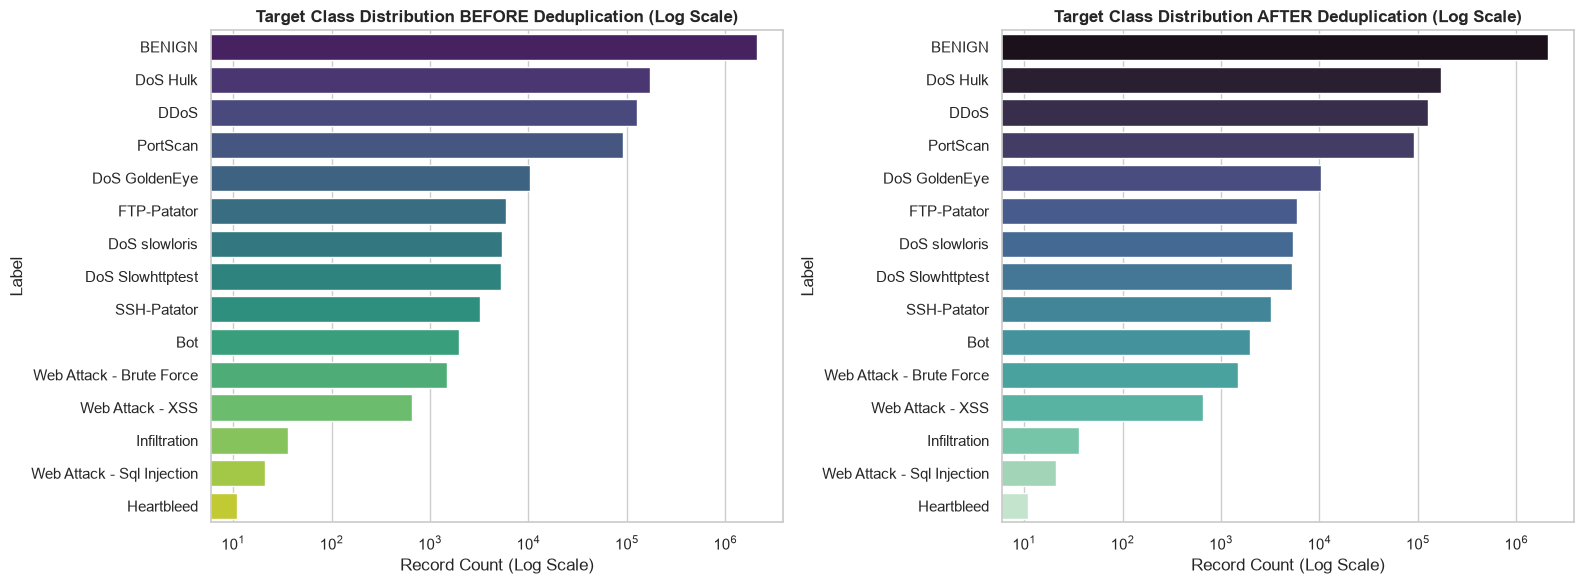

In [14]:
# 1. Class Distribution Before vs After Deduplication
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=multi_dist.values, y=multi_dist.index, ax=axes[0], palette='viridis', hue=multi_dist.index, legend=False)
axes[0].set_xscale('log')
axes[0].set_title('Target Class Distribution BEFORE Deduplication (Log Scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Record Count (Log Scale)')

after_dist = df['Label'].value_counts()
sns.barplot(x=after_dist.values, y=after_dist.index, ax=axes[1], palette='mako', hue=after_dist.index, legend=False)
axes[1].set_xscale('log')
axes[1].set_title('Target Class Distribution AFTER Deduplication (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Record Count (Log Scale)')

plt.tight_layout()
plt.show()

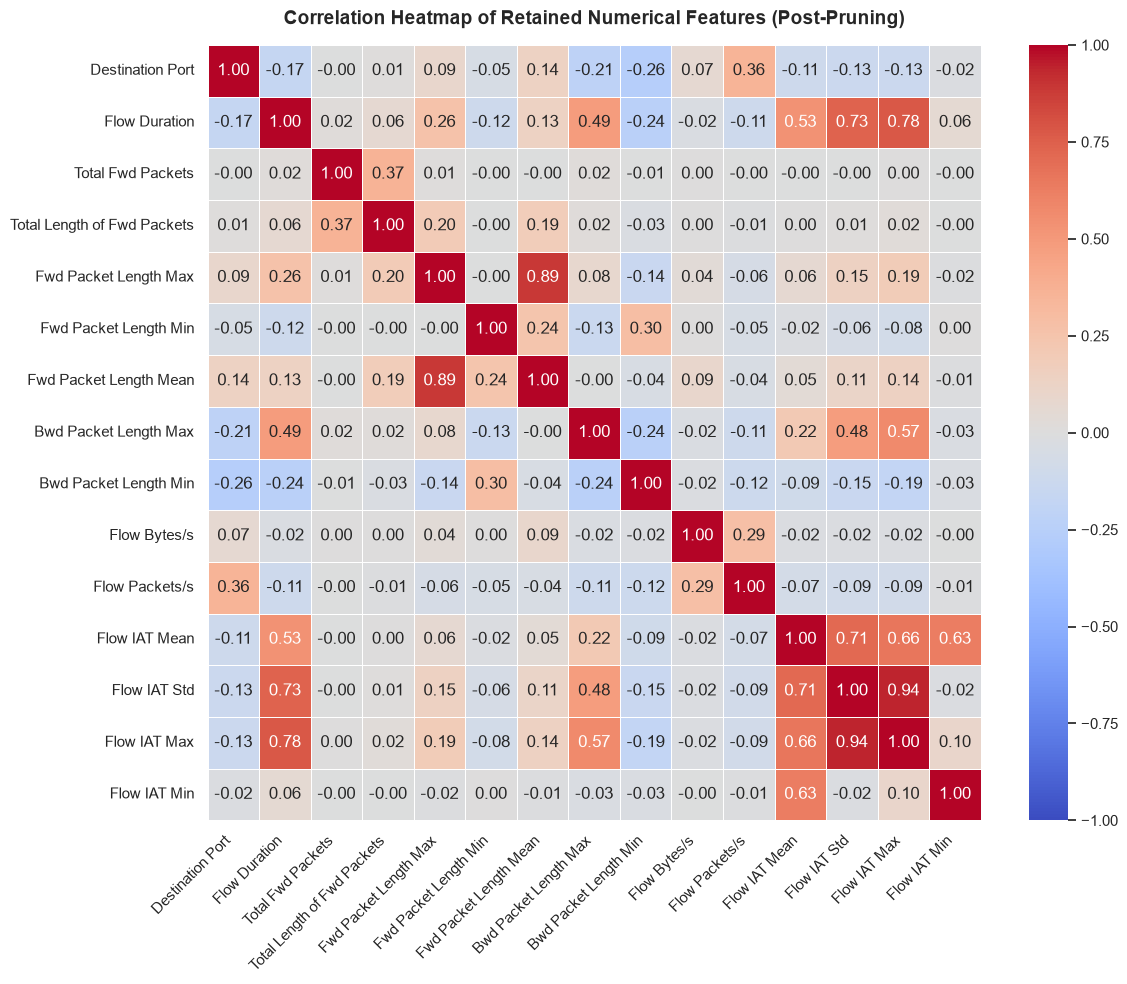

In [15]:
# 2. Correlation Heatmap of Retained Numerical Features (Subset of key features)
sample_retained = num_cols[:15]
corr_retained = df[sample_retained].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_retained, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Retained Numerical Features (Post-Pruning)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Step 18: Final Validation & Preprocessing Summary

In [16]:
# Automated Sanity Check Validation
assert train_df[num_cols].isna().sum().sum() == 0, "Validation Error: NaNs found in train features!"
assert test_df[num_cols].isna().sum().sum() == 0, "Validation Error: NaNs found in test features!"
assert np.isinf(train_df[num_cols].values).sum() == 0, "Validation Error: Infs found in train features!"
assert np.isinf(test_df[num_cols].values).sum() == 0, "Validation Error: Infs found in test features!"
assert train_df[num_cols].shape[1] == test_df[num_cols].shape[1], "Validation Error: Feature column mismatch!"
assert 'Label_Encoded' in train_df.columns and 'Traffic_Type_Encoded' in train_df.columns, "Validation Error: Missing target columns!"

validation_text = f"""
### AegisNet Phase 2 Preprocessing & Feature Engineering Summary

1. **Raw Input**: 2,830,743 records across 79 features loaded from 8 raw CIC-IDS2017 files.
2. **Deduplication**: Removed {dup_count:,} duplicate rows (10.89%), producing {dedup_count:,} clean flow records.
3. **Data Quality & Imputation**:
   - Converted {total_inf_before:,} infinity values and 2,127,515 negative TCP sentinel values to NaN.
   - Performed Median Imputation across all numerical features (0 missing values remaining).
4. **Feature Selection & Pruning**:
   - Dropped 9 non-predictive/constant features.
   - Dropped {len(collinear_removed_list)} redundant features with pairwise correlation |r| >= 0.95.
   - Retained {len(num_cols)} high-value numerical features.
5. **Target Processing & Stratified Split**:
   - Created Level 1 Binary Target (`Traffic_Type`: BENIGN vs ATTACK).
   - Encoded Level 2 Multiclass Target (`Label`: 15 classes).
   - Split into 80% Train ({len(train_df):,} rows) and 20% Test ({len(test_df):,} rows) with stratification.
6. **Outputs Saved**:
   - Datasets: `data/processed/cybersecurity/train.parquet` & `test.parquet`.
   - Artifacts: `models/preprocessing/label_encoder.joblib`, `binary_label_encoder.joblib`, `scaler.joblib`, `feature_names.json`, `preprocessing_config.json`.

**Status**: Phase 2 Preprocessing & Feature Engineering completed successfully with 0 errors! Ready for Phase 3 Baseline Model Training.
"""

display(Markdown(validation_text))
print("Validation Passed: All preprocessed outputs verified clean and complete!")


### AegisNet Phase 2 Preprocessing & Feature Engineering Summary

1. **Raw Input**: 2,830,743 records across 79 features loaded from 8 raw CIC-IDS2017 files.
2. **Deduplication**: Removed 308,381 duplicate rows (10.89%), producing 2,522,362 clean flow records.
3. **Data Quality & Imputation**:
   - Converted 2,775 infinity values and 2,127,515 negative TCP sentinel values to NaN.
   - Performed Median Imputation across all numerical features (0 missing values remaining).
4. **Feature Selection & Pruning**:
   - Dropped 9 non-predictive/constant features.
   - Dropped 23 redundant features with pairwise correlation |r| >= 0.95.
   - Retained 46 high-value numerical features.
5. **Target Processing & Stratified Split**:
   - Created Level 1 Binary Target (`Traffic_Type`: BENIGN vs ATTACK).
   - Encoded Level 2 Multiclass Target (`Label`: 15 classes).
   - Split into 80% Train (2,017,889 rows) and 20% Test (504,473 rows) with stratification.
6. **Outputs Saved**:
   - Datasets: `data/processed/cybersecurity/train.parquet` & `test.parquet`.
   - Artifacts: `models/preprocessing/label_encoder.joblib`, `binary_label_encoder.joblib`, `scaler.joblib`, `feature_names.json`, `preprocessing_config.json`.

**Status**: Phase 2 Preprocessing & Feature Engineering completed successfully with 0 errors! Ready for Phase 3 Baseline Model Training.


Validation Passed: All preprocessed outputs verified clean and complete!
